In [1]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import math

$$
Let\: \sqrt{n}(\widehat{\theta}_n - \theta)\xrightarrow{d}N(0,\sigma(\mu)^2) \: then \\
$$
$$
\widehat{\theta}_n \approx N(\theta, \frac{\sigma(\theta)^2}{n})
$$
then we can choose g and use delta method, in such way that:

$$ \sigma(\theta)^2\cdot[g'(\theta)]^2 = 1 $$
$$ \sigma(\theta)\cdot g'(\theta)=1$$
$$ g'(\theta) = \frac{1}{\sigma(\theta)} $$
$$ g(\theta) = \int \frac{d\theta}{\sigma(\theta)} $$

In [2]:
random.seed(42)

#Generate sample (Bernoulli distribution)
p = 0.02
n = 1000
sample = sc.stats.bernoulli.rvs(p, size=n)

Let's derive a new CI for Bernoulli distribution
$$ \sigma^2 = p(1 - p) $$
$$ \int \frac{dp}{p(1-p)} = 2 \cdot arcsin(\sqrt{p}) $$
thus
$$ 2\cdot arcsin(\sqrt{p}) \approx N(2\cdot arcsin(\sqrt{p}), \frac{1}{n}) $$

let's construct Wald's Interval for this distribution

$$ arcsin(\sqrt{p}) - \frac{Z_{1-\frac{\alpha}{2}}}{2\sqrt{n}} \le arcsin(\sqrt{p}) 
\le arcsin(\sqrt{p}) + \frac{Z_{1-\frac{\alpha}{2}}}{2\sqrt{n}} $$

Then our CI is:
$$ sin^2(arcsin(\sqrt{p}) \pm \frac{Z_{1-\frac{\alpha}{2}}}{2\sqrt{n}}) $$

Note:
$$ General\: form: \: g^{-1}(g(\widehat{\theta}_n) \pm \frac{Z_{1-\frac{\alpha}{2}}}{\sqrt{n}}) $$

Let's compare this result with Score Interval

In [3]:
def score_interval(x: np.ndarray, alpha: float) -> tuple:
    n = len(x) #sample size
    p_hat = x.mean()
    z = sc.stats.norm.ppf(1 - alpha / 2) #Quantile

    u = 1 / (1 + z**2 / n)
    center = u * p_hat + (1 - u) * 0.5

    radius = z * u * np.sqrt(p_hat * (1 - p_hat) / n + (1 - u) / (4 * u * n))
    return (center - radius, center + radius)

def new_interval(x: np.ndarray, alpha: float):
    n = len(x) #sample size
    p_hat = x.mean()
    z = sc.stats.norm.ppf(1 - alpha / 2) #Quantile

    center = np.arcsin(np.sqrt(p_hat))
    radius = z / (2 * np.sqrt(n))

    return (np.sin(center - radius) ** 2, np.sin(center + radius) ** 2)


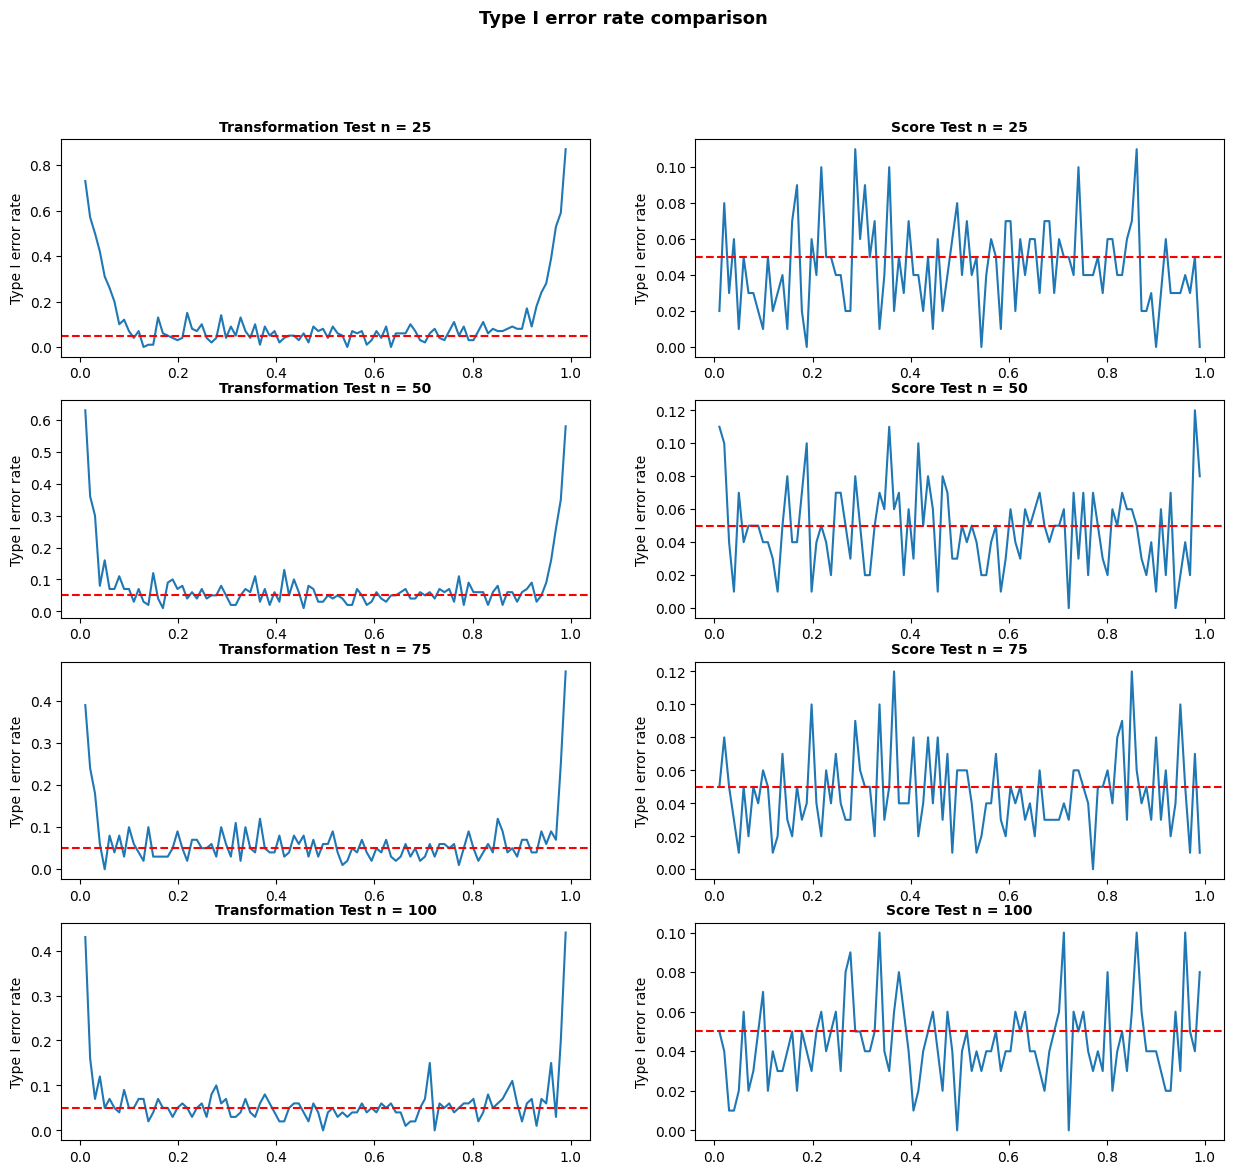

In [6]:
num_obs = [25, 50, 75, 100]
p = np.linspace(0.01, 0.99, 100)

#Visual
fig, ax = plt.subplots(4, 2, figsize=(15, 13))
fig.suptitle("Type I error rate comparison", fontweight='bold', fontsize=13)
for i in enumerate(num_obs):
    sample_size = i[1]
    proportions_wald, proportions_score = [], []

    for p_ in p:
        
        result = []
        for num_tests in range(100):
            sample = sc.stats.bernoulli.rvs(p_, size=sample_size) #True proportion = p_

            #Calculation of CI
            ci_new = new_interval(sample, 0.05)
            ci_score = score_interval(sample, 0.05)

            #H_0 = p_
            reject = lambda prob, ci : 1 if (ci[0] > prob or ci[1] < prob) else 0
            #reject = 1 if (ci[0] > p_ or ci[1] < p_) else 0
            result.append(reject(p_, ci_new))
            result.append(reject(p_, ci_score))
    
        #Type I error rate
        result = np.array(result)
        proportions_wald.append(result[0::2].mean())
        proportions_score.append(result[1::2].mean())
    
    cell_row, cell_col = i[0], 0
    cur_ax = ax[cell_row][cell_col]
    cur_ax.plot(p, proportions_wald)
    cur_ax.set_title(f"Transformation Test n = {sample_size}", fontweight='bold', fontsize=10)
    cur_ax.set_ylabel("Type I error rate")
    cur_ax.axhline(y=0.05, color="red", linestyle='--')

    cell_row, cell_col = i[0], 1
    cur_ax = ax[cell_row][cell_col]
    cur_ax.plot(p, proportions_score)
    cur_ax.set_title(f"Score Test n = {sample_size}", fontweight='bold', fontsize=10)
    cur_ax.set_ylabel("Type I error rate")
    cur_ax.axhline(y=0.05, color="red", linestyle='--')


In [5]:
sample = np.array(np.zeros(1000))
print(score_interval(sample, 0.05))
print(new_interval(sample, 0.05))

(3.686287386450715e-18, 0.003826758485555134)
(0.0009600573110816154, 0.0009600573110816154)


This interval also cannot collapse to a single point